<a href="https://colab.research.google.com/github/crajalakshmi-2226/Alfido-tech-internship/blob/main/copy_of_task1_ml_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# TASK 1 - ML CLASSIFICATION PROJECT

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:

# Step 2: Load Dataset

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Dataset loaded successfully!")
print("Features:", X.shape)
print("Target classes:", data.target_names)

Dataset loaded successfully!
Features: (569, 30)
Target classes: ['malignant' 'benign']


In [ ]:

# Step 3: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [ ]:

# Step 4: Train Two ML Models

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Create models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

# Train both models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "trained successfully!")

print("Both models trained successfully!")

Logistic Regression trained successfully!
Random Forest trained successfully!
Both models trained successfully!


In [ ]:

# Step 5: Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

results = []

for name, model in models.items():
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)

print("Model Evaluation Results:")
results_df

Model Evaluation Results:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993717


In [ ]:

from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

print("Cross-Validation Results:")
print(cv_df)

Cross-Validation Results:
                 Model  Mean CV Accuracy       Std
0  Logistic Regression          0.980686  0.006539
1        Random Forest          0.956094  0.022839



Logistic Regression


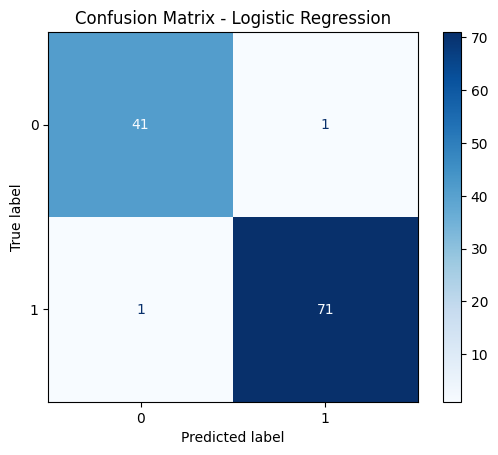


Random Forest


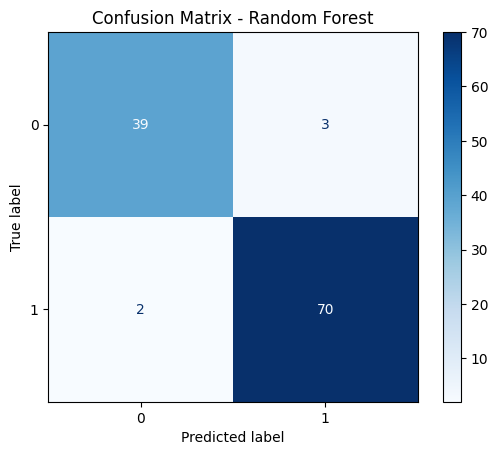

In [ ]:

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():
    print(f"\n{name}")

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [ ]:

print("Final Model Comparison")
print("=" * 50)

print(results_df.to_string(index=False))

print("\nCross-Validation Results")
print("=" * 50)

print(cv_df.to_string(index=False))

best_model = results_df.loc[
    results_df["Accuracy"].idxmax(), "Model"
]

print("\nBest Model based on Accuracy:", best_model)

Final Model Comparison
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
Logistic Regression  0.982456   0.986111 0.986111  0.986111 0.995370
      Random Forest  0.956140   0.958904 0.972222  0.965517 0.993717

Cross-Validation Results
              Model  Mean CV Accuracy      Std
Logistic Regression          0.980686 0.006539
      Random Forest          0.956094 0.022839

Best Model based on Accuracy: Logistic Regression


In [ ]:

print("PROJECT CONCLUSION")
print("=" * 50)

print("Project: Breast Cancer Classification")
print("Models Used: Logistic Regression and Random Forest")
print("Dataset: Breast Cancer Wisconsin Dataset")
print("Evaluation: Accuracy, Precision, Recall, F1-Score, ROC-AUC")
print("Validation: 5-Fold Cross-Validation")

print("\nBoth machine learning models were trained and evaluated.")
print("The model comparison was completed successfully.")

PROJECT CONCLUSION
Project: Breast Cancer Classification
Models Used: Logistic Regression and Random Forest
Dataset: Breast Cancer Wisconsin Dataset
Evaluation: Accuracy, Precision, Recall, F1-Score, ROC-AUC
Validation: 5-Fold Cross-Validation

Both machine learning models were trained and evaluated.
The model comparison was completed successfully.
